# Behavior-only window-size profiling for Task2

This notebook estimates a behavior-only window size for each subject in `data/processed/Task2_processed.csv`.

The score is:

`score(window) = sampling_var(window) + learning_var(window)`

- `sampling_var`: Bernoulli averaging variance, approximately `p_hat * (1 - p_hat) / window`.
- `learning_var`: variance of a lightly smoothed behavior curve inside each candidate window.

The selected window is the smallest candidate within 5% of the minimum score for that subject.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/processed/Task2_processed.csv')
OUT_DIR = Path('../results/window-size-profile/task2_behavior_only')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_WINDOWS = [4, 6, 8, 10, 12, 14, 16, 20, 24, 28, 32, 40, 48, 64, 80, 96, 128, 160, 192, 256, 320, 384, 512]
MAX_FRACTION = 1 / 3
MIN_WINDOWS = 8
WITHIN_PCT = 0.05

DATA_PATH, OUT_DIR

(PosixPath('../data/processed/Task2_processed.csv'),
 PosixPath('../results/window-size-profile/task2_behavior_only'))

In [2]:
def rolling_mean(arr, window):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < window:
        return np.array([], dtype=float)
    csum = np.cumsum(np.insert(arr, 0, 0.0))
    return (csum[window:] - csum[:-window]) / window


def rolling_var(arr, window):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < window:
        return np.array([], dtype=float)
    return np.asarray([
        float(np.nanvar(arr[start:start + window], ddof=0))
        for start in range(len(arr) - window + 1)
    ])


def profile_subject(correct_binary):
    y = np.asarray(correct_binary, dtype=float)
    n_trials = len(y)
    pilot_window = int(max(8, min(64, round(n_trials * 0.08))))
    pilot_curve = (
        pd.Series(y)
        .rolling(window=pilot_window, center=True, min_periods=max(2, pilot_window // 4))
        .mean()
        .interpolate(limit_direction='both')
        .to_numpy(dtype=float)
    )

    rows = []
    max_window = max(4, int(n_trials * MAX_FRACTION))
    for window in CANDIDATE_WINDOWS:
        if window > max_window:
            continue
        p_hat = rolling_mean(y, window)
        if p_hat.size < MIN_WINDOWS:
            continue

        sampling_var = float(np.nanmean(p_hat * (1.0 - p_hat) / window))
        learning_var = float(np.nanmean(rolling_var(pilot_curve, window)))
        score = sampling_var + learning_var
        rows.append({
            'n_trials': int(n_trials),
            'candidate_window': int(window),
            'max_allowed_window': int(max_window),
            'pilot_window': int(pilot_window),
            'sampling_var': sampling_var,
            'learning_var': learning_var,
            'score': score,
        })

    profile = pd.DataFrame(rows)
    if profile.empty:
        return profile, None

    min_score = float(profile['score'].min())
    eligible = profile[profile['score'] <= min_score * (1.0 + WITHIN_PCT)]
    selected_window = int(eligible.sort_values('candidate_window').iloc[0]['candidate_window'])
    return profile, selected_window

In [3]:
df = pd.read_csv(DATA_PATH)
sort_cols = [c for c in ['condition', 'iSub', 'iSession', 'iBlock', 'iTrial'] if c in df.columns]
df = df.sort_values(sort_cols).copy()

# Keep this consistent with optimizer_common.py, where true_acc is feedback == 1.0.
df['correct_binary'] = (df['feedback'] == 1.0).astype(float)

df.shape, df[['condition', 'iSub', 'iSession', 'iBlock', 'iTrial', 'feedback', 'correct_binary']].head()

((62736, 23),
    condition  iSub  iSession  iBlock  iTrial  feedback  correct_binary
 0          1   101         1       1       1       0.0             0.0
 1          1   101         1       1       2       1.0             1.0
 2          1   101         1       1       3       0.0             0.0
 3          1   101         1       1       4       0.0             0.0
 4          1   101         1       1       5       1.0             1.0)

In [4]:
profile_rows = []
summary_rows = []

# One recommendation per subject. `primary_condition` is the modal condition
# for that subject; `condition_values` records all conditions found in the CSV.
for subject, sub in df.groupby('iSub', sort=True):
    subject_profile, selected_window = profile_subject(sub['correct_binary'].to_numpy())
    if subject_profile.empty or selected_window is None:
        continue

    condition_counts = sub['condition'].value_counts().sort_index()
    condition_values = ','.join(str(int(c)) for c in condition_counts.index)
    primary_condition = int(condition_counts.idxmax())

    subject_profile.insert(0, 'primary_condition', primary_condition)
    subject_profile.insert(1, 'condition_values', condition_values)
    subject_profile.insert(2, 'iSub', int(subject))
    profile_rows.append(subject_profile)

    best = subject_profile.loc[subject_profile['score'].idxmin()]
    selected = subject_profile[subject_profile['candidate_window'] == selected_window].iloc[0]
    summary_rows.append({
        'iSub': int(subject),
        'primary_condition': primary_condition,
        'condition_values': condition_values,
        'n_trials': int(best['n_trials']),
        'max_allowed_window': int(best['max_allowed_window']),
        'max_evaluated_window': int(subject_profile['candidate_window'].max()),
        'pilot_window': int(best['pilot_window']),
        'min_score_window': int(best['candidate_window']),
        'selected_window_5pct': int(selected_window),
        'min_score': float(best['score']),
        'selected_score': float(selected['score']),
        'selected_sampling_var': float(selected['sampling_var']),
        'selected_learning_var': float(selected['learning_var']),
        'selected_at_max_candidate': bool(int(selected_window) == int(subject_profile['candidate_window'].max())),
        'min_at_max_candidate': bool(int(best['candidate_window']) == int(subject_profile['candidate_window'].max())),
    })

profile = pd.concat(profile_rows, ignore_index=True)
summary = pd.DataFrame(summary_rows).sort_values('iSub').reset_index(drop=True)
counts = summary.groupby(['primary_condition', 'selected_window_5pct']).size().unstack(fill_value=0)

profile.to_csv(OUT_DIR / 'window_profile_by_subject.csv', index=False)
summary.to_csv(OUT_DIR / 'window_profile_summary.csv', index=False)
counts.to_csv(OUT_DIR / 'selected_window_counts_by_condition.csv')

metadata = {
    'data_path': str(DATA_PATH),
    'candidate_windows': CANDIDATE_WINDOWS,
    'max_fraction_of_trials': MAX_FRACTION,
    'min_windows_per_subject_candidate': MIN_WINDOWS,
    'grouping': 'iSub',
    'selection_rule': f'smallest window within {WITHIN_PCT:.0%} of minimum behavior-only score',
    'correct_definition': 'feedback == 1.0',
    'score': 'sampling_var + learning_var',
    'condition_note': 'primary_condition is the modal condition per iSub; condition_values lists all conditions present for that iSub.',
}
(OUT_DIR / 'profile_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

summary

,iSub,primary_condition,condition_values,n_trials,max_allowed_window,max_evaluated_window,pilot_window,min_score_window,selected_window_5pct,min_score,selected_score,selected_sampling_var,selected_learning_var,selected_at_max_candidate,min_at_max_candidate
0,101,1,1,320,106,96,26,96,96,0.006576,0.006576,0.001416,0.005160,True,True
1,102,1,1,448,149,128,36,64,48,0.005997,0.006110,0.003665,0.002445,False,False
2,103,1,1,256,85,80,20,40,28,0.010384,0.010645,0.006577,0.004067,False,False
3,104,1,1,192,64,64,15,20,14,0.014202,0.014671,0.010349,0.004322,False,False
4,105,1,1,64,21,20,8,20,20,0.006746,0.006746,0.003411,0.003335,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,328,3,3,704,234,192,56,48,40,0.006824,0.007119,0.005267,0.001852,False,False
92,329,3,3,384,128,128,31,64,48,0.006270,0.006521,0.003824,0.002698,False,False
93,330,3,3,256,85,80,20,28,24,0.008390,0.008503,0.005623,0.002880,False,False
94,331,3,3,640,213,192,51,48,40,0.006635,0.006668,0.004634,0.002034,False,False


In [ ]:
counts

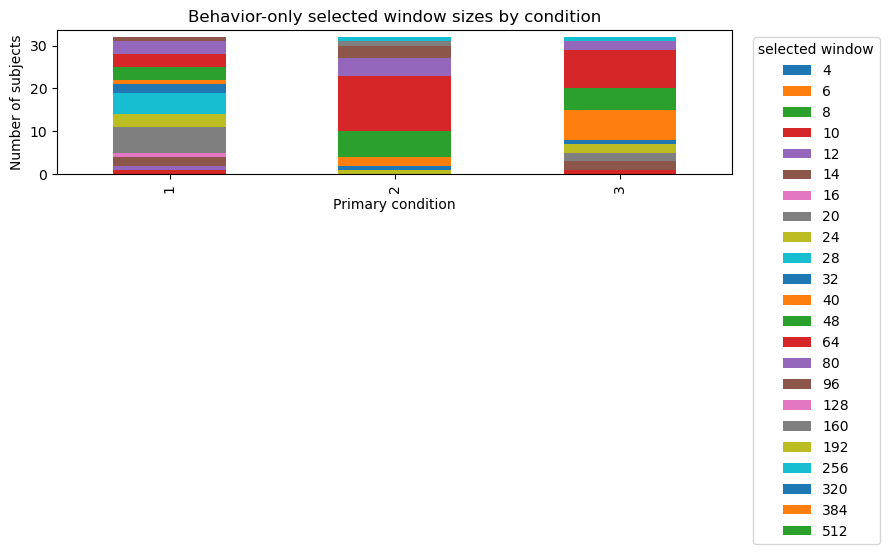

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
counts.reindex(columns=CANDIDATE_WINDOWS, fill_value=0).plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Primary condition')
ax.set_ylabel('Number of subjects')
ax.set_title('Behavior-only selected window sizes by condition')
ax.legend(title='selected window', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUT_DIR / 'selected_window_counts_by_condition.png', dpi=160)
plt.show()

,iSub,primary_condition,condition_values,n_trials,max_allowed_window,max_evaluated_window,pilot_window,min_score_window,selected_window_5pct,min_score,selected_score,selected_sampling_var,selected_learning_var,selected_at_max_candidate,min_at_max_candidate
0,101,1,1,320,106,96,26,96,96,0.006576,0.006576,0.001416,0.00516,True,True


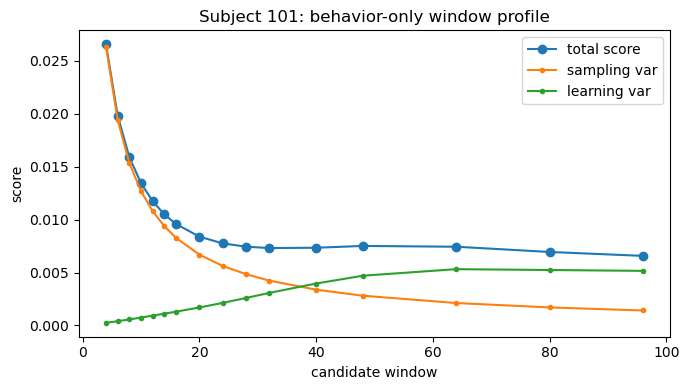

In [6]:
# Inspect one subject's score curve. Change SUBJECT_ID as needed.
SUBJECT_ID = int(summary.iloc[0]['iSub'])
one = profile[profile['iSub'] == SUBJECT_ID].copy()
display(summary[summary['iSub'] == SUBJECT_ID])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(one['candidate_window'], one['score'], marker='o', label='total score')
ax.plot(one['candidate_window'], one['sampling_var'], marker='.', label='sampling var')
ax.plot(one['candidate_window'], one['learning_var'], marker='.', label='learning var')
ax.set_xlabel('candidate window')
ax.set_ylabel('score')
ax.set_title(f'Subject {SUBJECT_ID}: behavior-only window profile')
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Plot every subject's score curve, grouped by condition.
def plot_condition_subject_profiles(condition, profile, out_dir, learning_weight=1, within_pct=WITHIN_PCT):
    cond_summary = (
        profile[profile['primary_condition'] == condition][['iSub']]
        .drop_duplicates()
        .sort_values('iSub')
    )
    condition_profile = profile[profile['primary_condition'] == condition]
    max_x = int(condition_profile['candidate_window'].max())
    xticks = [tick for tick in [4, 16, 32, 64, 128, 256, 512] if tick <= max_x]
    if max_x not in xticks:
        xticks.append(max_x)
    fig, axes = plt.subplots(4, 8, figsize=(24, 12), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, cond_summary.iterrows()):
        sid = int(row['iSub'])
        one = profile[profile['iSub'] == sid].sort_values('candidate_window').copy()
        one['weighted_learning_var'] = learning_weight * one['learning_var']
        one['weighted_score'] = one['sampling_var'] + one['weighted_learning_var']
        min_score = float(one['weighted_score'].min())
        eligible = one[one['weighted_score'] <= min_score * (1.0 + within_pct)]
        selected_w = int(eligible.sort_values('candidate_window').iloc[0]['candidate_window'])
        min_w = int(one.loc[one['weighted_score'].idxmin(), 'candidate_window'])

        ax.plot(one['candidate_window'], one['weighted_score'], marker='o', ms=3, lw=1.2, label='weighted score')
        ax.plot(one['candidate_window'], one['sampling_var'], marker='.', ms=2.5, lw=0.9, label='sampling')
        ax.plot(one['candidate_window'], one['weighted_learning_var'], marker='.', ms=2.5, lw=0.9, label='lambda * learning')
        ax.axvline(selected_w, color='tab:red', ls='--', lw=1.0)
        if min_w != selected_w:
            ax.axvline(min_w, color='0.45', ls=':', lw=0.9)

        ax.set_title(f'Sub {sid} | sel={selected_w}, min={min_w}', fontsize=9)
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(alpha=0.2, lw=0.5)
        ax.set_xlim(4, max_x)
        ax.set_xticks(xticks)

    for ax in axes[len(cond_summary):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.965), ncol=3, frameon=False, fontsize=11)
    fig.suptitle(f'Behavior-only window-size profiles | condition {condition} | lambda={learning_weight:g}', fontsize=16, y=0.995)
    fig.supxlabel('candidate window size', fontsize=12)
    fig.supylabel('weighted score component', fontsize=12)
    fig.tight_layout(rect=[0.02, 0.04, 1.0, 0.93])

    out_path = out_dir / f'window_profile_cond{condition}_lambda{learning_weight:g}.png'
    fig.savefig(out_path, dpi=180)
    plt.show()
    return out_path


saved_profile_figures = [
    plot_condition_subject_profiles(condition, profile, OUT_DIR, learning_weight=learning_weight)
    for learning_weight in [1, 2, 3]
    for condition in sorted(summary['primary_condition'].unique())
]
saved_profile_figures